# M1 — static lead-specific Gaussian copula

This notebook derives M1 without assuming another notebook. Read [Chapters 3--5](../../docs/scientific/03_chronos_and_pit.md) for PIT construction, dependence, and estimation.

## Notation, observation, and estimand

$i\in[N]$ indexes origin $t^{(i)}$, $g$ indexes the static set $\mathcal E_g=\{k_1,\ldots,k_{K_g}\}$, and $\tau\in[H]$ is one-based lead. $Y_{k,\tau}^{(i)}$ is random, $y_{k,\tau}^{(i)}$ is observed, $F_{k,\tau}^{(i)}$ is the fixed marginal, and $A_{g,\tau}^{(i)}=\sum_kY_{k,\tau}^{(i)}$ is the random aggregate. The observation is mapped to pseudo-PIT $u_{k,\tau}^{(i)}$ and score $z_{k,\tau}^{(i)}=\Phi^{-1}(u_{k,\tau}^{(i)})$. Define entity validity $V_{k,\tau}^{(i)}\in\{0,1\}$ and complete validity $V_{g,\tau}^{(i)}=\prod_{k\in\mathcal E_g}V_{k,\tau}^{(i)}$. The vector $\mathbf z_{g,\tau}^{(i)}\in\mathbb R^{K_g}$ exists only when this product is one. M1 estimates persistent same-lead association in these vectors.

## Estimator

For each lead, training vectors produce a Ledoit--Wolf covariance $\widehat\Sigma_{g,\tau}^{LW}$, a shrinkage estimator that moves the empirical covariance toward a well-conditioned structured target. It is normalized to
$$\widehat R_{ab}=\widehat\Sigma_{ab}/\sqrt{\widehat\Sigma_{aa}\widehat\Sigma_{bb}}.$$
After symmetric positive-definite stabilization, the same $\widehat R_{g,\tau}$ is used at every validation and test origin. M1 can represent positive and negative association, but not origin-dependent association.

In [6]:
from pathlib import Path
import sys, numpy as np, matplotlib.pyplot as plt, torch
PROJECT_ROOT=next(p for p in (Path.cwd(),*Path.cwd().parents) if (p/'pyproject.toml').is_file())
CACHE_ROOT=PROJECT_ROOT/'artifacts'/'cache'
if str(PROJECT_ROOT/'src') not in sys.path: sys.path.insert(0,str(PROJECT_ROOT/'src'))
from simcast.config import load_base_config, load_method_config, resolve_run_config
from simcast.experiments import locate_compatible_cache
from simcast.fm.cache import load_pit_library
from simcast.fm.pit import dependence_pit_scores
from simcast.dependence.static_gaussian import StaticGaussianCopula
from simcast.sampling.gaussian_copula import generate_scenarios, sample_gaussian_uniforms
from simcast.cli.train_dependence import train_from_config
from simcast.cli.evaluate import evaluate_from_config
BASE_FILE='configs/bases/liander2024/solar_park.yaml'
METHOD_FILE='configs/methods/m1_static_gaussian.yaml'
BASE_OVERRIDES=(f'output.cache_dir={CACHE_ROOT}',); METHOD_OVERRIDES=()
FIT_IN_MEMORY=True; FIT_IF_MISSING=True; RUN_EVALUATION=True  # In-memory M1 is read-only; the latter controls can write artifacts.
RUN_DIR=PROJECT_ROOT/'runs'/'notebook_walkthrough'/'m1_static'
base=load_base_config(PROJECT_ROOT/BASE_FILE,overrides=BASE_OVERRIDES)
method=load_method_config(PROJECT_ROOT/METHOD_FILE,overrides=METHOD_OVERRIDES)
config=resolve_run_config(base,method)
cache_dir=locate_compatible_cache(base)
library=load_pit_library(cache_dir,access='training'); ds=library.dataset
entity_ids=[str(x) for x in ds.entity_id.values]; K_g=len(entity_ids)
print({'g':base.data.entity_type,'K_g':K_g,'share_across_leads':method.model.share_across_leads})


{'g': 'solar_park', 'K_g': 5, 'share_across_leads': False}


## Optional in-memory estimate for interpretation

This cell does not write an artifact. When `FIT_IN_MEMORY=True`, it fits exactly the M1 estimator to training-visible complete vectors and displays one lead. This is descriptive inspection, not a registered test evaluation.

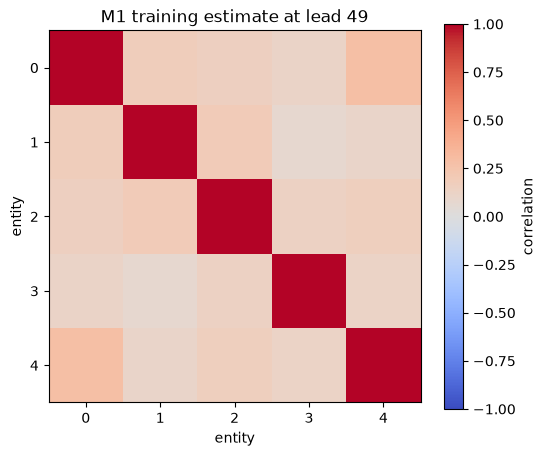

In [ ]:
if FIT_IN_MEMORY:
    train=np.asarray(ds['split'].values)=='train'
    scores,_=dependence_pit_scores(torch.tensor(np.asarray(ds['pit_u'].values).copy()),torch.tensor(np.asarray(ds['pit_z'].values).copy()),torch.tensor(train.copy()),torch.tensor(np.asarray(ds['quantile'].values).copy()),mode=config.pit.dependence_transform,eps=config.pit.eps)
    z=scores.numpy()[train]
    s=method.model
    model=StaticGaussianCopula(share_across_leads=s.share_across_leads,jitter=s.jitter).fit(z,entity_ids)
    lead_index=len(ds['lead'])//2; lead_value=int(ds['lead'].values[lead_index]); R=np.asarray(model.correlation_matrix(lead_value))
    fig,ax=plt.subplots(figsize=(6,5)); im=ax.imshow(R,vmin=-1,vmax=1,cmap='coolwarm')
    ax.set(title=f'M1 training estimate at lead {lead_value}',xlabel='entity',ylabel='entity'); fig.colorbar(im,ax=ax,label='correlation'); plt.show()
else:
    print('Set FIT_IN_MEMORY=True to estimate M1 from training pseudo-scores.')

## Observed scores and the fitted M1 Gaussian law

At the displayed lead, the left panel contains the complete historical training vectors used by M1. The right panel contains draws from $\mathcal N(\mathbf 0,\widehat R_{g,\tau})$. The entity pair is chosen by the largest absolute off-diagonal element of $\widehat R_{g,\tau}$. This comparison shows the rank association retained by M1; it is not an out-of-sample goodness-of-fit test.

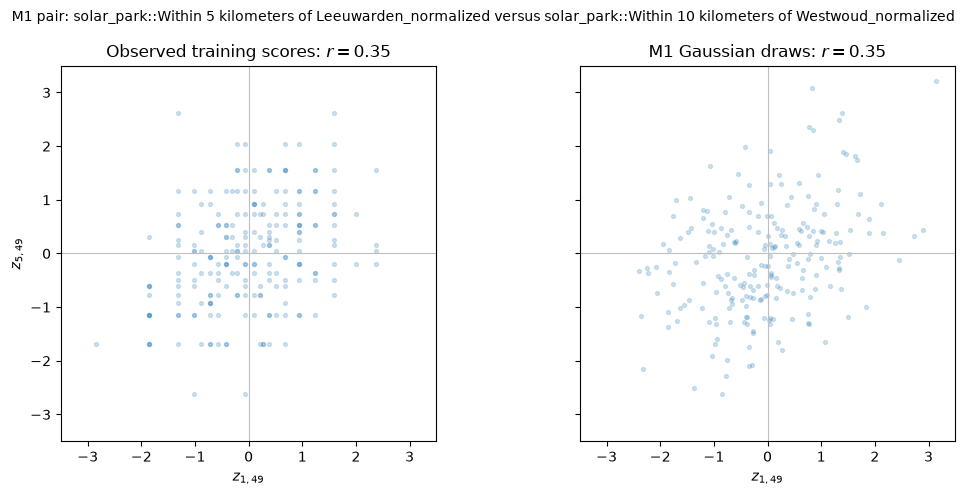

In [8]:
if FIT_IN_MEMORY:
    lead_scores=z[:,:,lead_index]; lead_scores=lead_scores[np.isfinite(lead_scores).all(axis=1)]
    strength=np.abs(R.copy()); np.fill_diagonal(strength,-np.inf); entity_a,entity_b=map(int,np.unravel_index(np.argmax(strength),strength.shape))
    generator=torch.Generator().manual_seed(config.sampling.evaluation_seed)
    fitted_u=sample_gaussian_uniforms(torch.tensor(R,dtype=torch.float32),len(lead_scores),generator=generator); fitted_z=torch.special.ndtri(fitted_u).numpy()
    step=max(1,len(lead_scores)//5000); observed_pair=lead_scores[::step][:,[entity_a,entity_b]]; fitted_pair=fitted_z[::step][:,[entity_a,entity_b]]
    limit=max(3.5,float(np.nanpercentile(np.abs(np.vstack((observed_pair,fitted_pair))),99.5)))
    fig,axes=plt.subplots(1,2,figsize=(11,5),sharex=True,sharey=True)
    panels=((observed_pair,fr'Observed training scores: $r={np.corrcoef(lead_scores,rowvar=False)[entity_a,entity_b]:.2f}$'),(fitted_pair,fr'M1 Gaussian draws: $r={np.corrcoef(fitted_z,rowvar=False)[entity_a,entity_b]:.2f}$'))
    for ax,(points,title) in zip(axes,panels):
        ax.scatter(points[:,0],points[:,1],s=8,alpha=.2); ax.axhline(0,color='0.75',lw=.8); ax.axvline(0,color='0.75',lw=.8); ax.set(xlim=(-limit,limit),ylim=(-limit,limit),aspect='equal',title=title,xlabel=fr'$z_{{{entity_a+1},{lead_value}}}$')
    axes[0].set_ylabel(fr'$z_{{{entity_b+1},{lead_value}}}$'); fig.suptitle(f'M1 pair: {entity_ids[entity_a]} versus {entity_ids[entity_b]}',fontsize=10); plt.tight_layout(); plt.show()
else: print('Enable FIT_IN_MEMORY to compare observed and M1-generated scores.')


## From M1 ranks to physical and aggregate scenarios

For a valid training case, M1 draws $X^{(m)}\sim\mathcal N(\mathbf0,\widehat R_{g,\tau})$, maps $U_k^{(m)}=\Phi(X_k^{(m)})$, and applies each entity's fixed inverse marginal law. The panels trace those same draws through correlated probability ranks, physical entity scenarios, and the aggregate $\widetilde A_{g,\tau}^{(i,m)}=\sum_k\widetilde Y_{k,\tau}^{(i,m)}$.

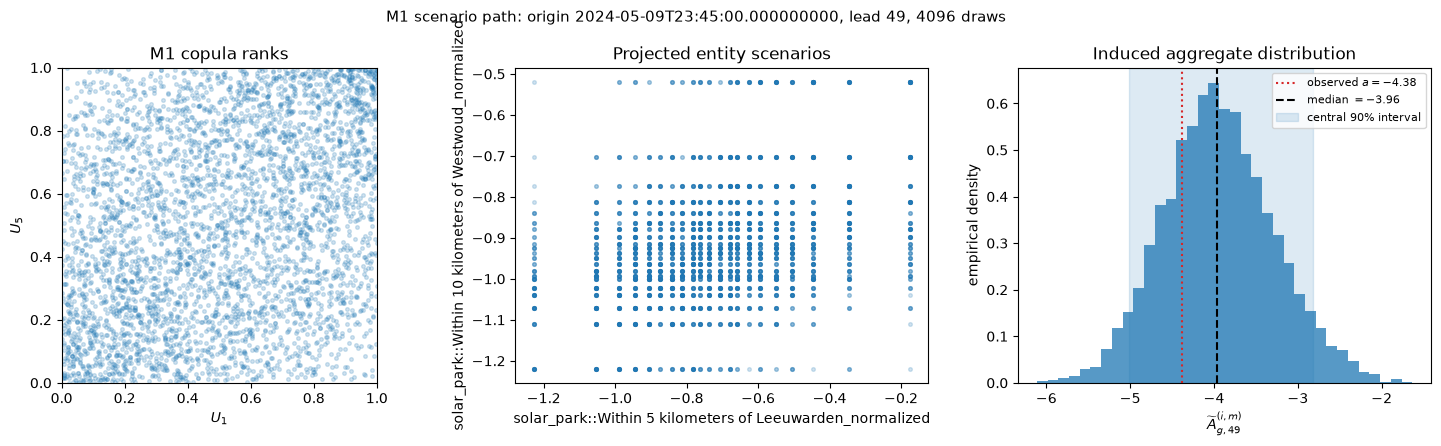

In [9]:
if FIT_IN_MEMORY:
    candidates=np.flatnonzero(train & np.asarray(ds['pit_valid'].values,dtype=bool)[:,lead_index])
    if not candidates.size: raise ValueError(f'No valid training origin exists at lead {lead_value}.')
    origin_index=int(candidates[len(candidates)//2]); quantile_grid=torch.tensor(np.asarray(ds['quantile_prediction'].values[origin_index,:,lead_index,:]).copy(),dtype=torch.float32)
    generator=torch.Generator().manual_seed(config.sampling.evaluation_seed); scenarios=generate_scenarios(torch.tensor(R,dtype=torch.float32),quantile_grid,torch.tensor(np.asarray(ds['quantile'].values).copy(),dtype=torch.float32),num_samples=config.sampling.num_samples,generator=generator,marginal_mode=config.pit.mode)
    u=scenarios.uniforms.numpy(); y=scenarios.entity_samples.numpy(); aggregate=scenarios.aggregate_samples.numpy(); observed_aggregate=float(np.asarray(ds['true_y'].values)[origin_index,:,lead_index].sum()); q05,q50,q95=np.quantile(aggregate,[.05,.5,.95])
    fig,axes=plt.subplots(1,3,figsize=(15,4.5)); axes[0].scatter(u[:,entity_a],u[:,entity_b],s=7,alpha=.2); axes[0].set(xlim=(0,1),ylim=(0,1),aspect='equal',xlabel=fr'$U_{{{entity_a+1}}}$',ylabel=fr'$U_{{{entity_b+1}}}$',title='M1 copula ranks')
    axes[1].scatter(y[:,entity_a],y[:,entity_b],s=7,alpha=.2); axes[1].set(xlabel=entity_ids[entity_a],ylabel=entity_ids[entity_b],title='Projected entity scenarios')
    axes[2].hist(aggregate,bins=35,density=True,alpha=.75); axes[2].axvline(observed_aggregate,color='C3',ls=':',label=fr'observed $a={observed_aggregate:.3g}$'); axes[2].axvline(q50,color='black',ls='--',label=fr'median $={q50:.3g}$'); axes[2].axvspan(q05,q95,color='C0',alpha=.15,label='central 90% interval'); axes[2].set(xlabel=fr'$\widetilde A_{{g,{lead_value}}}^{{(i,m)}}$',ylabel='empirical density',title='Induced aggregate distribution'); axes[2].legend(fontsize=8)
    origin_label=str(ds['origin_timestamp'].values[origin_index]); fig.suptitle(f'M1 scenario path: origin {origin_label}, lead {lead_value}, {config.sampling.num_samples} draws',fontsize=11); plt.tight_layout(); plt.show()
else: print('Enable FIT_IN_MEMORY to visualize M1 scenario generation.')


## Optional authoritative training and evaluation

These controls are false by default. The functions are identical to the CLI path and preserve cache validation, full-group assertions, saved metadata, and sealed test access.

In [11]:
if FIT_IF_MISSING and not (RUN_DIR/'model.npz').is_file():
    train_from_config(config,cache_dir=cache_dir,output_dir=RUN_DIR)
if RUN_EVALUATION:
    evaluate_from_config(config,methods=('static_gaussian',),method_runs={'static_gaussian':RUN_DIR},cache_dir=cache_dir,output_dir=RUN_DIR/'evaluation')


## Interpretation and controls

The covariance estimator is Ledoit--Wolf; `share_across_leads: false` gives $H$ matrices and `true` pools all leads; `jitter` controls stabilization. M1 has no feature or optimization section because its estimator is closed-form. `StaticGaussianCopula` implements the estimate. A gain over M0 indicates persistent residual rank dependence. A conditional method's gain over M1 asks whether dependence varies predictably with origin context.